# EDA - Claims & Frequency

In [13]:
from statistics import variance

import statsmodels
import numpy as np
from databricks.connect import DatabricksSession
from pyspark.sql import functions
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
spark = DatabricksSession.builder.getOrCreate()

In [2]:
CATALOG = "commercial-insurance-underwriting-solution-catalog"
SEED = 42
policy = spark.table(f"`{CATALOG}`.silver.policy")

## Exploring the Policy dataset

- Each id tracked to see how many years it has been used - signalling renewal since new business?

In [3]:
policy_year_per_id = policy.groupBy('ID').count().withColumnRenamed('count', 'number_of_year_of_policy')
policy_year_per_id.groupBy('number_of_year_of_policy').count().withColumnRenamed('count', 'n_policy').orderBy('number_of_year_of_policy').show()

I0911 21:01:06.646217 6928493 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(93, generation: 1)
I0911 21:01:06.646378 6928493 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(93, generation: 1)
I0911 21:01:06.646384 6928493 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(93, generation: 1)
I0911 21:01:06.646387 6928493 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(93, generation: 1)
I0911 21:01:06.646391 6928493 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(93, generation: 1)
I0911 21:01:06.646396 6928493 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(93, generation: 1)
I0911 21:01:06.646399 6928493 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(93, generation: 1)
I0911 21:01:06.646402 6928493 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(93, generation: 1)
I0911 21:01:06.646404 6928493 ev_poll_posix.cc:593] FD from fork parent still in poll li

+------------------------+--------+
|number_of_year_of_policy|n_policy|
+------------------------+--------+
|                       1|   20579|
|                       2|   14685|
|                       3|   17346|
|                       4|     892|
+------------------------+--------+



- An example to trace

In [4]:
example_id = policy_year_per_id.filter('number_of_year_of_policy == 4').first()['ID']
policy.filter(functions.col("ID") == example_id).orderBy("Date_last_renewal").select(
      "ID", "Date_start_contract", "Date_last_renewal", "Date_next_renewal",
      "Premium", "Cost_claims_year", "N_claims_year", "Type_risk", "Area", "Power",
  ).show(truncate=False)

+---+-------------------+-----------------+-----------------+-------+----------------+-------------+---------+----+-----+
|ID |Date_start_contract|Date_last_renewal|Date_next_renewal|Premium|Cost_claims_year|N_claims_year|Type_risk|Area|Power|
+---+-------------------+-----------------+-----------------+-------+----------------+-------------+---------+----+-----+
|1  |2015-11-05         |2015-11-05       |2016-11-05       |222.52 |0.0             |0            |1        |0   |80   |
|1  |2015-11-05         |2016-11-05       |2017-11-05       |213.78 |0.0             |0            |1        |0   |80   |
|1  |2015-11-05         |2017-11-05       |2018-11-05       |214.84 |0.0             |0            |1        |0   |80   |
|1  |2015-11-05         |2018-11-05       |2019-11-05       |216.99 |0.0             |0            |1        |0   |80   |
+---+-------------------+-----------------+-----------------+-------+----------------+-------------+---------+----+-----+



- Does each policy since new business line up year after year before churn?

In [5]:
w = Window.partitionBy('ID').orderBy('Date_last_renewal')
chained_policies = policy.withColumn('previous_next_renewal', functions.lag('Date_next_renewal').over(w)).withColumn('row_number', functions.row_number().over(w))
chained_policies.filter(functions.col('row_number') > 1).withColumn('chains_correctly', functions.col('Date_last_renewal') ==  functions.col('previous_next_renewal')).groupBy('chains_correctly').count().show()

+----------------+-----+
|chains_correctly|count|
+----------------+-----+
|            true|52053|
+----------------+-----+



- Lets look up the key target variables distribution
- We have confirmed that the n_claims_year for each row is all 1 year. this makes it the frequency meet the definition `claims_count/exposure`. Here the N_claims_count is the claims count the exposure is one year. N_claims_count will be renamed `Frequency`
- `Cost_claims_year` is the pure premium/total loss cost. Severity is defined as `Loss/claims_count`. As such severity will be calculated as ``

## Drilling into the Claims frequency

In [6]:
freq_severity = (
    policy
    .select('ID', 'N_claims_year', 'Cost_claims_year')
    .withColumn(
        'Severity',
        functions.when(functions.col('N_claims_year')>0,
        functions.col('Cost_claims_year')/functions.col('N_claims_year')
        )
    )
    .withColumnRenamed('N_claims_year', 'Frequency')
).toPandas()

In [7]:
frequency = freq_severity['Frequency']
frequency.describe()

count    105555.000000
mean          0.394695
std           1.105018
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          25.000000
Name: Frequency, dtype: float64

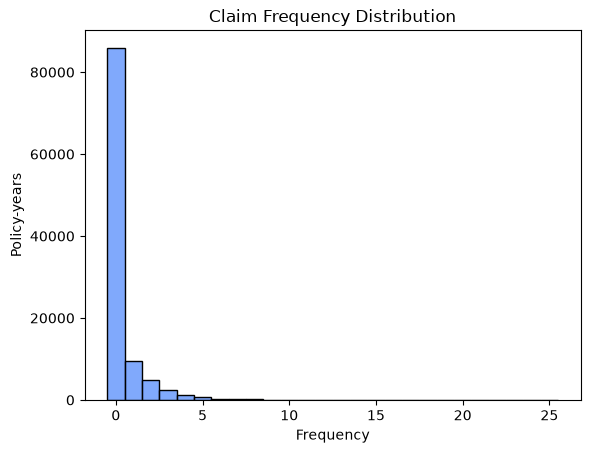

In [8]:
sns.histplot(frequency, discrete=True)
plt.xlabel('Frequency')
plt.ylabel('Policy-years')
plt.title(f'Claim Frequency Distribution')
plt.show()

In [ ]:
threshold = 8
tail = freq_severity[freq_severity['Frequency'] > threshold].sort_values('Frequency', ascending=False)
plot_data = freq_severity[freq_severity['Frequency'] <= threshold]
sns.histplot(plot_data['Frequency'], discrete=True)
plt.xlabel('Frequency')
plt.ylabel('Policy-years')
plt.title(f'Claim Frequency Distribution (excluding Frequency > {threshold})')
plt.show()
# print(f"tail: {tail}")

- The histogram above reveals that the claims frequency is zero-inflated and is right skewed following the poisson distrubtion. I will be running a few checks to confirm that poisson assumptions are met. i.e mean is approx equal the variance. There are few ways to do this.

In [ ]:
# Method 1 - Using dispersion ratio - this is the smoke detector that suggest that if > 1 overdispersion needs to be drilled in
mean_f = frequency.mean()
var_f = frequency.var()
dispersion_ratio = var_f/mean_f
print(f"dispersion_ratio: {dispersion_ratio:.4f}")

In [ ]:
## Method 2: Fit a poisson model using a dummy exposure + calculate the pearson residual -> square it up and sum it to produce the pearson chi-square statistic. Divide the pearson statistic by degrees of freedom. If the poisson assumption that variance = mean then the output (squared standardised residual) should average out to 1. In this case the claims frequency has 3x more variance than poisson accounts for. Note - this does not mean that frequency fit to feature will give the same output.
import statsmodels.api as sm
import statsmodels.formula.api as smf
poisson_model = smf.glm('frequency ~ 1', data=frequency, family=sm.families.Poisson()).fit()
pearson_chi2 = poisson_model.pearson_chi2
dof = poisson_model.df_resid
print(f"Pearson chi2 / dof: {pearson_chi2/dof:.3f}")

In [ ]:
## Lets compare the zeros in the dataset to what we would expect from a poisson generation process. As in this case we see a 14percentage point more zeros in the dataset that the poisson implied process

import numpy as np
n = len(frequency)
observed_p0 = (frequency == 0).mean()
poisson_implied_p0 = np.exp(-mean_f)

print(f"Observed P(0): {observed_p0:.4f}")
print(f"Poisson-implied P(0): {poisson_implied_p0:.4f}")
print(f"Excess zeros: {observed_p0 - poisson_implied_p0:.4f}")

- The distribution is right-skewed with a large zero mass (~86% of policy-years), consistent with a low-mean count process. n=[X] policies exceed a Frequency of 8, with a maximum of [25] -  flagged for investigation as potential outliers/data quality issues before modelling.
- Mean frequency = [x], variance = [y], giving a dispersion ratio of 3.094.variance substantially exceeds mean, violating the Poisson equidispersion assumption.Fitting an intercept-only Poisson GLM cross-confirms this via Pearson χ²/dof (≈3.0), consistent with the ratio above.
- Observed zero proportion (81.4%) substantially exceeds the Poisson-implied zero proportion (67.4%) given the fitted mean — an excess of 14 percentage points.
- This shows two distinct violations of the Poisson assumption: general overdispersion (unobserved heterogeneity across policies) and excess-zero mechanism. This jointly motivates prioritizing Zero-Inflated Negative Binomial (ZINB) as a leading algorithm candidate that handles both violations simultaneously

In [18]:
## Lets look at a contingent table for claims frequency  & then a correlation matrix as well
policy_df = policy.toPandas()

In [ ]:
distribution_channel_map = {0: 'Agent', 1: 'Insurance Broker'}
payment_map = {0: 'Annual', 1: 'Half-yearly'}
type_risk_map = {1: 'Motorbike', 2: 'Van', 3: 'Passenger Car', 4: 'Agricultural Vehicle'}
area_map = {0: 'Rural', 1: 'Urban'}
second_driver_map = {0: 'Single Driver', 1: 'Multiple Drivers'}

policy_df['Distribution_channel_lbl'] = policy_df['Distribution_channel'].map(distribution_channel_map)
policy_df['Payment_lbl'] = policy_df['Payment'].map(payment_map)
policy_df['Type_risk_lbl'] = policy_df['Type_risk'].map(type_risk_map)
policy_df['Area_lbl'] = policy_df['Area'].map(area_map)
policy_df['Second_driver_lbl'] = policy_df['Second_driver'].map(second_driver_map)

policy_df['Claims_Frequency_binned'] = pd.cut(
    policy_df['N_claims_year'],
    bins=[-1, 0, 1, 2, 3, np.inf],
    labels=['0', '1', '2', '3', '4+']
)

In [ ]:
category = 'Area_lbl'
contingency = pd.crosstab(policy_df['Claims_Frequency_binned'], policy_df[category])
plt.figure(figsize=(10, 6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues')
plt.title('Claim Frequency (binned) vs. Type of Risk - categorical')
plt.xlabel('Type of Risk')
plt.ylabel('Claims Frequency (binned)')
plt.tight_layout()
plt.show()

In [ ]:
categories = ['Area_lbl', 'Type_risk_lbl', 'Distribution_channel_lbl',
              'Payment_lbl', 'Second_driver_lbl']

n_cols = 2
n_rows = int(np.ceil(len(categories) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()  # so we can index it flatly regardless of grid shape

for i, category in enumerate(categories):
    contingency = pd.crosstab(policy_df['Claims_Frequency_binned'], policy_df[category])

    sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=True)
    axes[i].set_title(f'Claim Frequency vs. {category}')
    axes[i].set_xlabel(category)
    axes[i].set_ylabel('Claims Frequency (binned)')

# hide any unused subplot axes if categories doesn't evenly fill the grid
for j in range(len(categories), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
numeric_for_corr = [
    'N_claims_year', 'Seniority', 'Policies_in_force', 'Premium',
    'N_claims_history', 'R_Claims_history',
    'Power', 'Cylinder_capacity', 'Value_vehicle', 'N_doors', 'Length', 'Weight'
]

corr_matrix = policy_df[numeric_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix (continuous/count variables)')
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix_spearman = policy_df[numeric_for_corr].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix (Spearman)')
plt.tight_layout()
plt.show()

## Drilling into Claims Severity

In [9]:
# test = freq_severity['Severity']
severity = freq_severity["Severity"].dropna()   ##note that this drop na actually drops off all  policies with 0 claim. remeber that severity = total loss cost / number of calims so if there is no claims, it return null
severity.describe()

count     19646.000000
mean        467.096236
std        1568.012175
min           4.006923
25%          64.460000
50%         154.230000
75%         474.555000
max      118142.590000
Name: Severity, dtype: float64

- Its worth nothing that the maximum severity is over 100k yet 75th percentile is less than 500. This suggest that there are a few large losses that heavily skew the data.
- There are few ways this can be handled. Use domain knowledge to separate attritional losses from  large losses OR bin the outliers using a decently chosen threshold e.g top 1% OR conduct a mean excess plot to choose a defnesible outlier threshold
- Here a judegment number is chosen as `>10,000` and the top 1 % are binned for this exploration. Note in reality a judgement number could be preferred in production becaue its a definition, top 1% may shift out based on input distirbtion over time

In [14]:
def capped_histogram(data, threshold, n_bins=30, ax=None, title=None):
  body = data[data <= threshold]
  overflow_count = (data > threshold).sum()

  counts, bin_edges = np.histogram(body, bins=n_bins, range=(0, threshold))
  bin_width = bin_edges[1] - bin_edges[0]

  if ax is None:
      fig, ax = plt.subplots(figsize=(10, 6))

  ax.bar(bin_edges[:-1], counts, width=bin_width, align='edge',
         edgecolor='black', color='steelblue', label='body')
  ax.bar(threshold, overflow_count, width=bin_width, align='edge',
         edgecolor='black', color='firebrick', label=f'{threshold:,.0f}+')

  ax.set_xlabel('Claim severity ($)')
  ax.set_ylabel('Count')
  ax.set_title(title)
  ax.legend()

  return ax, overflow_count

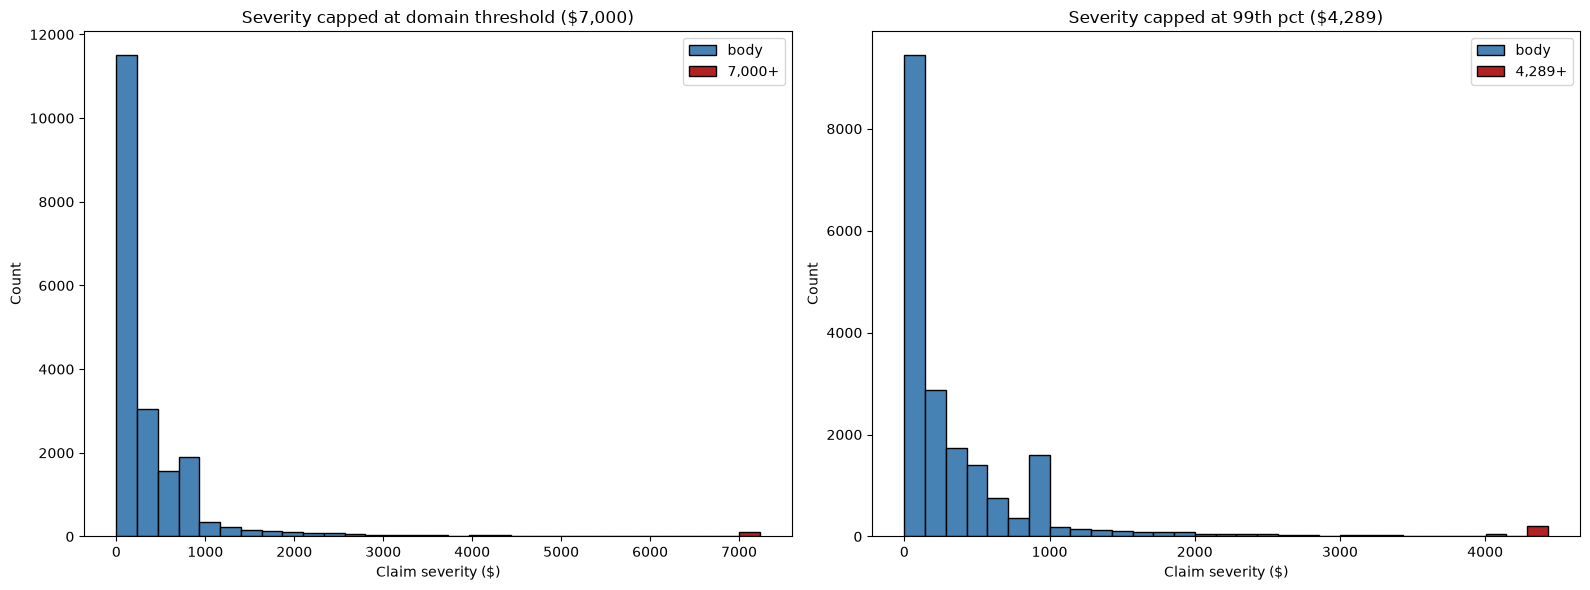

Domain threshold ($7,000): 98 claims in overflow bin (0.09% of claims)
99th pct threshold ($4,289): 197 claims in overflow bin (0.19% of claims)


In [43]:
threshold_domain = 7_000
threshold_pctile = severity.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

_, overflow_domain = capped_histogram(
  severity, threshold_domain, n_bins=30, ax=axes[0],
  title=f'Severity capped at domain threshold (${threshold_domain:,.0f})'
)
_, overflow_pctile = capped_histogram(
  severity, threshold_pctile, n_bins=30, ax=axes[1],
  title=f'Severity capped at 99th pct (${threshold_pctile:,.0f})'
)

plt.tight_layout()
plt.show()

print(f"Domain threshold (${threshold_domain:,.0f}): {overflow_domain} claims in overflow bin "
    f"({overflow_domain / len(policy_df['Cost_claims_year']):.2%} of claims)")
print(f"99th pct threshold (${threshold_pctile:,.0f}): {overflow_pctile} claims in overflow bin "
    f"({overflow_pctile / len(policy_df['Cost_claims_year']):.2%} of claims)")

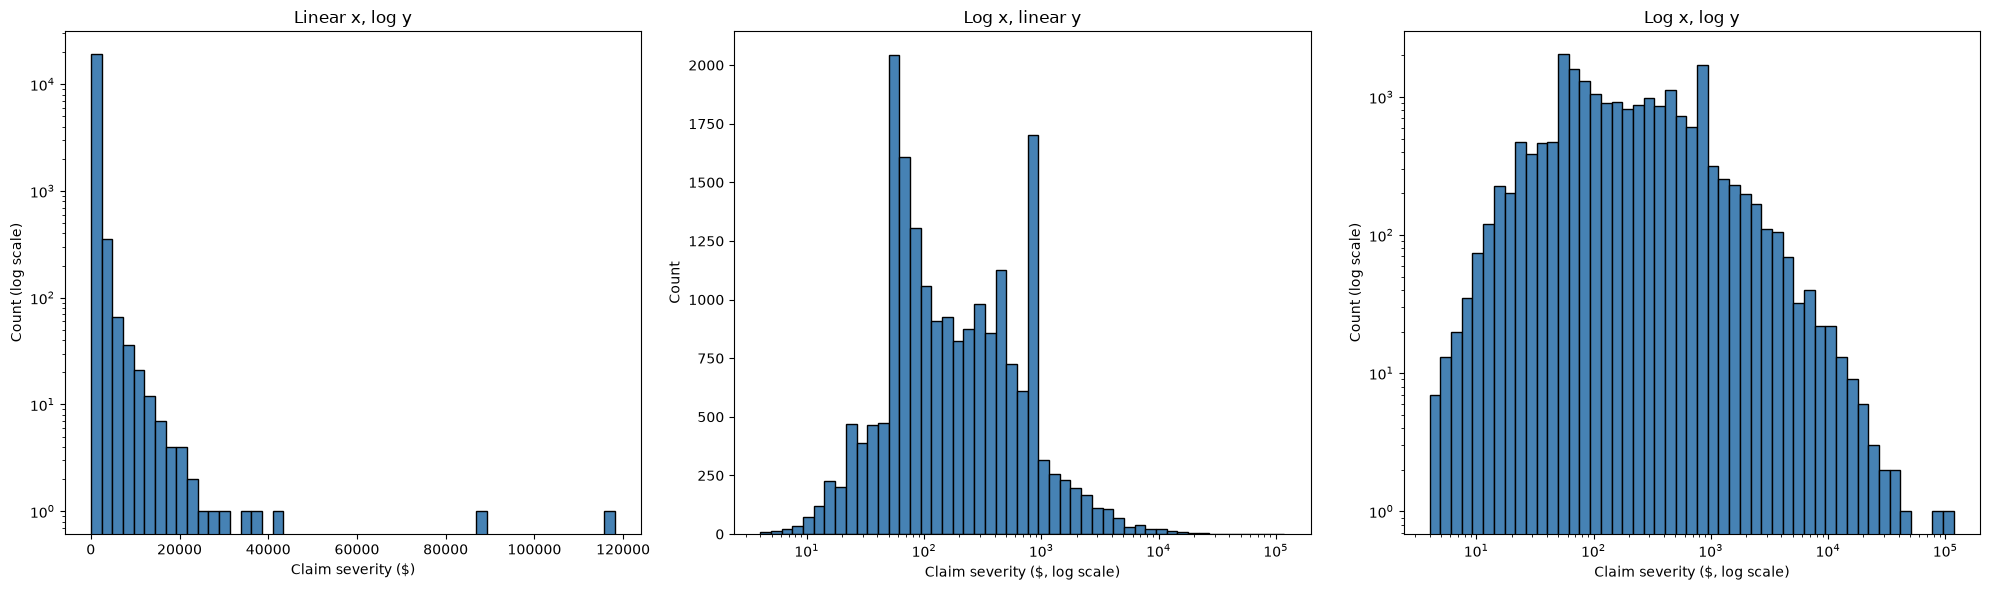

In [16]:
n_bins = 50
linear_bin_edges = np.linspace(severity.min(), severity.max(), n_bins)
log_bin_edges = np.logspace(np.log10(severity.min()), np.log10(severity.max()), n_bins)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].hist(severity, bins=linear_bin_edges, edgecolor='black', color='steelblue')
axes[0].set_yscale('log')
axes[0].set_xlabel('Claim severity ($)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Linear x, log y')

axes[1].hist(severity, bins=log_bin_edges, edgecolor='black', color='steelblue')
axes[1].set_xscale('log')
axes[1].set_xlabel('Claim severity ($, log scale)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log x, linear y')

axes[2].hist(severity, bins=log_bin_edges, edgecolor='black', color='steelblue')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_xlabel('Claim severity ($, log scale)')
axes[2].set_ylabel('Count (log scale)')
axes[2].set_title('Log x, log y')

plt.tight_layout()
plt.show()

- So from the last panel that log transforms both axis (count and severity values), the distribution of the data shows that its bimodal with gradually ascending head and decaying tail, extreme outlier are also seen
- The distribution of this severity dataset could be gamma, lognormal, weibull or even pareto. so conducting a format test for each and using aic and bic to see to see which distrubtion/model fits best

In [ ]:
from scipy import stats

n = len(severity)

gamma_params = stats.gamma.fit(severity, floc=0)  # loc fixed at 0: severity is strictly positive, unfixed loc is unstable
gamma_ks = stats.kstest(severity, 'gamma', args=gamma_params)
gamma_loglik = np.sum(stats.gamma.logpdf(severity, *gamma_params))
print(f"Gamma (a, loc, scale) = {gamma_params}")
print(f"KS stat: {gamma_ks.statistic:.4f}, p-value: {gamma_ks.pvalue:.4g}")

lognorm_params = stats.lognorm.fit(severity, floc=0)
lognorm_ks = stats.kstest(severity, 'lognorm', args=lognorm_params)
lognorm_loglik = np.sum(stats.lognorm.logpdf(severity, *lognorm_params))
print(f"Lognormal (s, loc, scale) = {lognorm_params}")
print(f"KS stat: {lognorm_ks.statistic:.4f}, p-value: {lognorm_ks.pvalue:.4g}")

weibull_params = stats.weibull_min.fit(severity, floc=0)
weibull_ks = stats.kstest(severity, 'weibull_min', args=weibull_params)
weibull_loglik = np.sum(stats.weibull_min.logpdf(severity, *weibull_params))
print(f"Weibull (c, loc, scale) = {weibull_params}")
print(f"KS stat: {weibull_ks.statistic:.4f}, p-value: {weibull_ks.pvalue:.4g}")

- To understand the above we conduct the [Kolmogorov-Smirnov Test](https://www.geeksforgeeks.org/machine-learning/kolmogorov-smirnov-test-ks-test/) - simply put it compares probability distributions and see if they differ signficantly using kstatistic - Maximum vertical deviation between EDF and CDF
- Pvalues for all 3 distributions is 0 which means - we reject null hypothesis that data follows any of the 3 distributions. However, the ks statistic is least for lognormal followed by weibull test and gamma comes last

In [ ]:
def aic_bic(loglik, n_params, n_obs):
  aic = 2 * n_params - 2 * loglik
  bic = n_params * np.log(n_obs) - 2 * loglik
  return aic, bic

fit_results = pd.DataFrame([
  {'distribution': 'Gamma', 'k': 2, 'loglik': gamma_loglik},
  {'distribution': 'Lognormal', 'k': 2, 'loglik': lognorm_loglik},
  {'distribution': 'Weibull', 'k': 2, 'loglik': weibull_loglik},
])
fit_results[['AIC', 'BIC']] = fit_results.apply(
  lambda row: pd.Series(aic_bic(row['loglik'], row['k'], n)), axis=1
)
fit_results.sort_values('AIC')

Both AIC and BIC do the same basic job: pick the "best" model out of several candidates by balancing two things that pull in opposite directions — how well it fits the data, and how
  many parameters it needed to get that fit.

The formulas, side by side:

- AIC = 2k − 2·loglik
- BIC = k·ln(n) − 2·loglik

Both start from the same place: −2·loglik (bigger log-likelihood = better fit = this term gets more negative = lower AIC/BIC = "better"). The only difference is the penalty added per
parameter (k):

- AIC charges a flat 2 points per parameter, no matter how much data you have. AIC is more forgiving of extra complexity if it meaningfully improves it (i.e will make better predictions)
- BIC charges ln(n) points per parameter — and that penalty grows as your sample grows. With your n=19,646, ln(19,646) ≈ 9.9 — so BIC is punishing each extra parameter roughly 5x
harder than AIC is, in this dataset. BIC is going to make judge complexity more harshly
- Lower is better here implies that lognormal again is best fit with minimal complexity for both AIC/BIC followed by weibull and then pareto

In [ ]:
policy_df['Severity_binned'] = pd.qcut(
  policy_df['Severity'].dropna(),
  q=[0, .25, .5, .75, .9, 1.0],
  labels=['Q1 (low)', 'Q2', 'Q3', 'Q4', 'Top 10%']
)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, category in enumerate(categories):
  contingency = pd.crosstab(policy_df['Severity_binned'], policy_df[category])
  sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=True)
  axes[i].set_title(f'Claim Severity vs. {category}')
  axes[i].set_xlabel(category)
  axes[i].set_ylabel('Claim Severity (binned)')

for j in range(len(categories), len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
numeric_for_corr_severity = numeric_for_corr + ['Severity']

corr_pearson = policy_df[numeric_for_corr_severity].corr()
corr_spearman = policy_df[numeric_for_corr_severity].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation incl. Severity (Pearson)')

sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation incl. Severity (Spearman)')

plt.tight_layout()
plt.show()

## Drilling into Loss Cost/Pure Premium

In [22]:
policy_df['Cost_claims_year'].describe()

count    105555.000000
mean        153.557305
std        1477.112362
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      260853.240000
Name: Cost_claims_year, dtype: float64

- Looking at the estimate of location, this is heavily skewed on the tail with large loss - more specifically the 75th percentile is 0. One of the easiest way to evaluate the disribtion of the body would be to cap the large loss to observe the distibution based on domain thresholds or pin point location

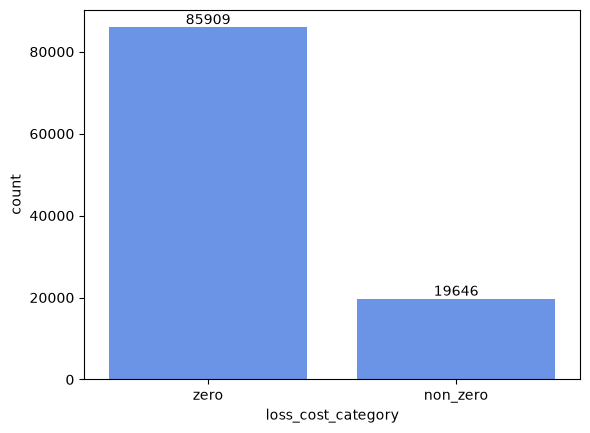

In [56]:
import numpy as np
policy_df['loss_cost_category'] =  np.where(policy_df['Cost_claims_year'] ==0, 'zero', 'non_zero')
ax = sns.countplot(x='loss_cost_category', data=policy_df)
for _ in ax.containers:
    ax.bar_label(_)

- Similar to claimes frequency, over 80% of the have 0 as the lost cost value

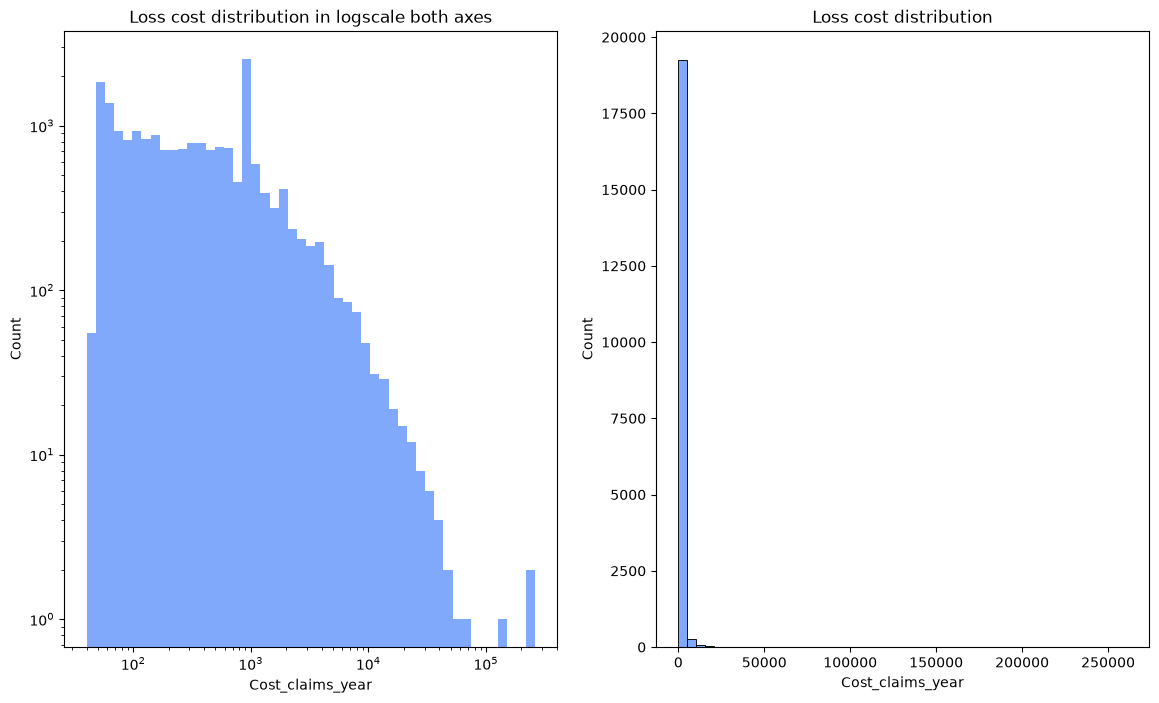

In [38]:
non_zero_loss_cost_policy_df = policy_df[policy_df['Cost_claims_year'] >0]
log_bin_edges = np.logspace(np.log10(non_zero_loss_cost_policy_df['Cost_claims_year'].min()),
                            np.log10(non_zero_loss_cost_policy_df['Cost_claims_year'].max()), n_bins)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 8))

sns.histplot(data=non_zero_loss_cost_policy_df, bins=log_bin_edges, x='Cost_claims_year', ax=ax[0])
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_title('Loss cost distribution in logscale both axes')


sns.histplot(data=non_zero_loss_cost_policy_df, bins=50, x='Cost_claims_year', ax=ax[1])
ax[1].set_title('Loss cost distribution')
plt.show()

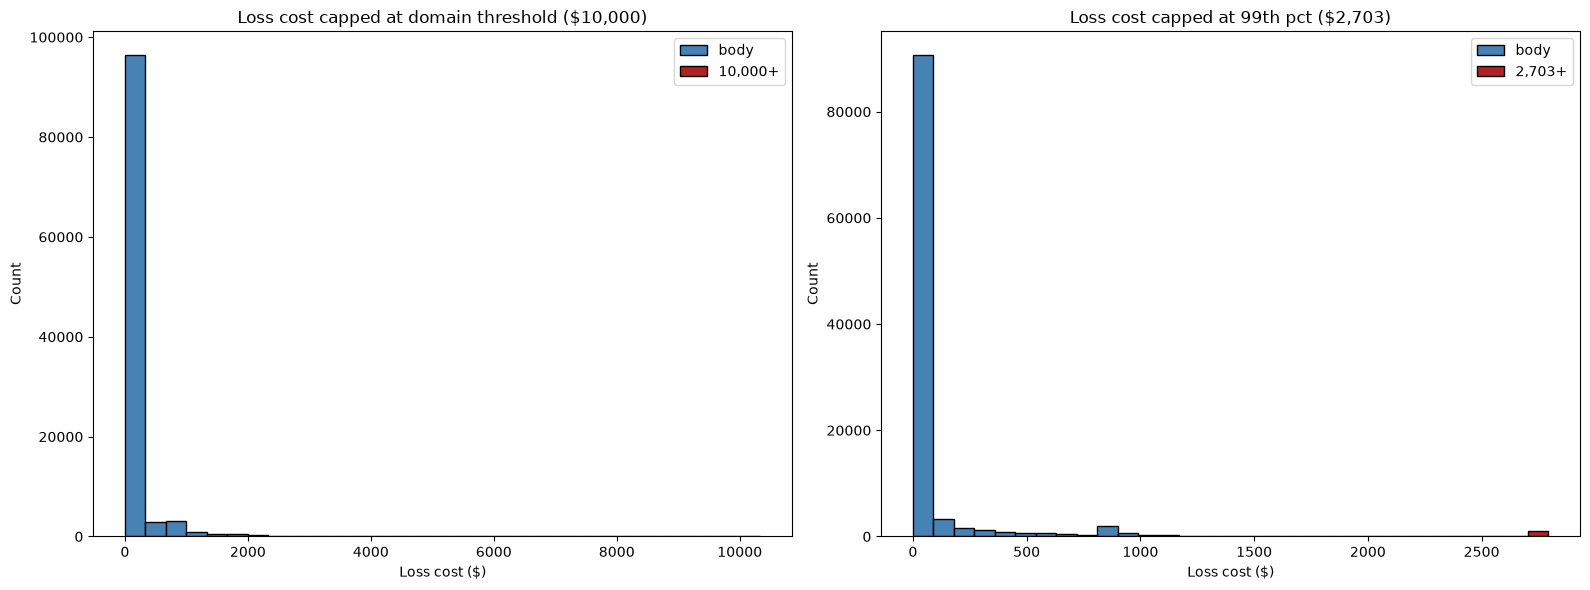

Domain threshold ($10,000): 142 claims in overflow bin (0.13% of claims)
99th pct threshold ($2,703): 1056 claims in overflow bin (5.38% of claims)


In [45]:
def capped_histogram(data, threshold, n_bins=30, ax=None, title=None):
  body = data[data <= threshold]
  overflow_count = (data > threshold).sum()

  counts, bin_edges = np.histogram(body, bins=n_bins, range=(0, threshold))
  bin_width = bin_edges[1] - bin_edges[0]

  if ax is None:
      fig, ax = plt.subplots(figsize=(10, 6))

  ax.bar(bin_edges[:-1], counts, width=bin_width, align='edge',
         edgecolor='black', color='steelblue', label='body')
  ax.bar(threshold, overflow_count, width=bin_width, align='edge',
         edgecolor='black', color='firebrick', label=f'{threshold:,.0f}+')

  ax.set_xlabel('Loss cost ($)')
  ax.set_ylabel('Count')
  ax.set_title(title)
  ax.legend()

  return ax, overflow_count

threshold_domain = 10_000
threshold_pctile = policy_df['Cost_claims_year'].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

_, overflow_domain = capped_histogram(
  policy_df['Cost_claims_year'], threshold_domain, n_bins=30, ax=axes[0],
  title=f'Loss cost capped at domain threshold (${threshold_domain:,.0f})'
)
_, overflow_pctile = capped_histogram(
  policy_df['Cost_claims_year'], threshold_pctile, n_bins=30, ax=axes[1],
  title=f'Loss cost capped at 99th pct (${threshold_pctile:,.0f})'
)

plt.tight_layout()
plt.show()

print(f"Domain threshold (${threshold_domain:,.0f}): {overflow_domain} claims in overflow bin "
    f"({overflow_domain / len(policy_df['Cost_claims_year']):.2%} of claims)")
print(f"99th pct threshold (${threshold_pctile:,.0f}): {overflow_pctile} claims in overflow bin "
    f"({overflow_pctile / len(severity):.2%} of claims)")

In [55]:
## Compute the total percentage of the loss cost that falls into the top 1%/5%/10%. This will mean not considering the year on year or month on month element to this as a first cut - Done on the full dataset not the nonzero ones

total_loss_cost = policy_df['Cost_claims_year'].sum()

top_shares = [0.01, 0.05, 0.10]
rows = []
for share in top_shares:
  threshold = policy_df['Cost_claims_year'].quantile(1 - share)
  above_threshold = policy_df.loc[policy_df['Cost_claims_year'] > threshold, 'Cost_claims_year']
  rows.append({
      'top_pct_of_policies': f'{share:.0%}',
      'loss_cost_threshold': threshold,
      'n_policies_above_threshold': above_threshold.count(),
      'pct_of_total_loss_cost': above_threshold.sum() / total_loss_cost,
  })

loss_cost_concentration = pd.DataFrame(rows)
loss_cost_concentration


,top_pct_of_policies,loss_cost_threshold,n_policies_above_threshold,pct_of_total_loss_cost
0,1%,2702.796,1056,0.460836
1,5%,882.000,3831,0.702462
2,10%,241.386,10556,0.940683


## Looking into the distributional assumption check
The problem it's solving: Most policies have $0 in claims. A few have huge claims. Nothing in between is smooth - it's a pile of zeros, then a scattering  of real dollar amounts. Standard distributions (Normal, Gamma, Poisson alone) don't handle "pile of zeros + continuous dollar amounts" well. Tweedie is a  distribution family built specifically for this shape - it is used to model total claim cost per policy.

The "p" parameter: Tweedie has a dial called p that controls the mix:
- p = 1 → behaves like Poisson (just counts, no dollar-amount spread, everything is 0/1/2/3 claims)
- p = 2 → behaves like Gamma (no zeros at all, just a smooth spread of dollar amounts)
- p between 1 and 2 → the realistic case: lots of zeros, plus continuous dollar amounts when a claim does happen

You need to know what p is before you can fit a Tweedie model, because it's a knob you set, not something the model figures out for you.

How to find it:
1. Split your policies into groups (e.g. by region, vehicle age, whatever).
2. For each group, compute two numbers: the average loss cost, and the variance (how spread out the losses are) in that group.
3. Plot log(variance) against log(mean) for all your groups.
4. Draw a straight line through those points. The slope of that line is your p.

Why this works: Tweedie distributions have a mathematical rule that variance = mean^p (times a constant). Taking logs turns that into a straight line
(log(variance) = p * log(mean) + constant), so the slope of the line you fit is a direct estimate of p. You're not guessing p - so we'd be reading it off the data.

Why it matters here: If the estimated p comes out around 1.5-1.7 (typical for insurance), that confirms Tweedie is the right tool and tells you what p to plug in. If it comes out weird (like exactly 1 or exactly 2), that's a signal your data doesn't actually look like compound Poisson-Gamma and you should rethink the model.




There are a number of way to do exploration of the p parameter for tweedie
- Empirical mean-variance log-linear regression
      - Group your data by distinct categorical features or quantiles of continuous features
      - Calculate the mean and variance of your target variable within each group.
      - Fit a simple linear regression where the dependent variable is and the independent variable
      - The resulting slope coefficient is your empirical estimate for.

- Fit an intecerpt only baseline  model over a grid search of cancdiate p values to maximise the profile log-likelhood


In [78]:
from tweedie import tweedie

p_value_grids = np.arange(1.05, 2, 0.05)

y = policy_df['Cost_claims_year']
x = np.ones((len(y), 1))

results = []
for p in p_value_grids:
    family = sm.families.Tweedie(link=sm.families.links.Log(), var_power=p)
    fit = sm.GLM(y, x, family=family).fit()
    mu, phi = fit.mu, fit.scale
    loglik = tweedie(mu=mu, p=p, phi=phi).logpdf(y).sum()
    results.append({'p': p, 'llf': loglik})
profile_df = pd.DataFrame(results)

In [79]:
best_row = profile_df.loc[profile_df['llf'].idxmax()]
print(f"Best p = {best_row['p']:.2f}, log-likelihood = {best_row['llf']:.2f}")

Best p = 1.85, log-likelihood = -217580.92


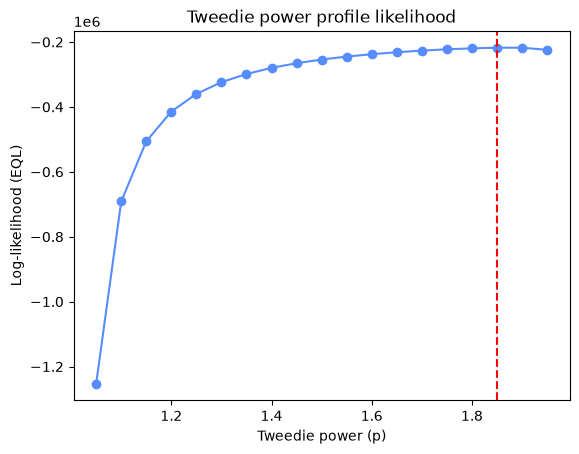

In [80]:
plt.plot(profile_df['p'], profile_df['llf'], marker='o')
plt.axvline(best_row['p'], color='red', linestyle='--')
plt.xlabel('Tweedie power (p)')
plt.ylabel('Log-likelihood (EQL)')
plt.title('Tweedie power profile likelihood')
plt.show()

- With this we can see a slight dip at p=1.85 which can be further confirmed by limiting the p values to somewhere between 1.6 to 2 to make the deep conspicous. This indicates that the p falls between 1 and 2 sitting more toward the tail end near 2. This implies that the variablility in the loss cost in dominated by the size of claims when they occur not by the frequency of occurrence. This seems consistent with earlier findings that top 10% of policies account for 94% of total loss cost.
- Now we have an idea of p when fitting the actual tweedie model